<a href="https://colab.research.google.com/github/kkandanala9/Hello-World/blob/master/DTSC_4050/Week_8_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 Class Activity — Estimation
**Computational and Inferential Thinking**

This notebook covers the following topics:

1. **Percentiles**
2. **The Bootstrap**
3. **Confidence Intervals**
4. **Using Confidence Intervals**

### Learning goals
- Calculate and interpret percentiles and quartiles.
- Distinguish a population parameter from a sample statistic.
- Explain why bootstrap samples are drawn **with replacement** and with the **same sample size**.
- Generate a bootstrap distribution.
- Construct confidence intervals for means, medians, and proportions.



## Part 1 — Percentiles

Chapter 13 begins with percentiles because percentile cutoffs are used later to construct bootstrap confidence intervals.

For a collection of values, the **p-th percentile** is the smallest value that is at least as large as *p%* of the values.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(4050)

# Five continent sizes (million square miles), following the chapter example
sizes = np.array([12, 17, 6, 9, 7])
np.sort(sizes)


### Activity 1A
Before running the next cell, determine by hand:

1. The 80th percentile
2. The 70th percentile
3. The median



In [24]:
# NumPy's 'higher' method matches the book's percentile definition closely.
def book_percentile(p, values):
    return np.percentile(values, p, method='nearest')

print("70th percentile:", book_percentile(70, sizes))
print("80th percentile:", book_percentile(80, sizes))
print("Median:", book_percentile(50, sizes))


70th percentile: 12
80th percentile: 12
Median: 9


### Quartiles
- Q1 = 25th percentile
- Q2 = 50th percentile = median
- Q3 = 75th percentile

The interval from Q1 to Q3 contains the **middle 50%** of the data.


In [25]:
scores = np.array([8, 10, 11, 12, 13, 15, 16, 16, 17, 18, 20, 20, 21, 22, 22, 24])

for p in [25, 50, 75, 85]:
    print(f"{p}th percentile:", book_percentile(p, scores))


25th percentile: 13
50th percentile: 17
75th percentile: 20
85th percentile: 22


---

## Part 2 — Population, Parameter, Sample, and Statistic

Suppose the entire array below represents a population of employee compensations.

The **population median** is a *parameter*. Usually we do not know it because we cannot observe the entire population.

We therefore draw a random sample and use its median as a *statistic* that estimates the parameter.


Population median (parameter): $126,822


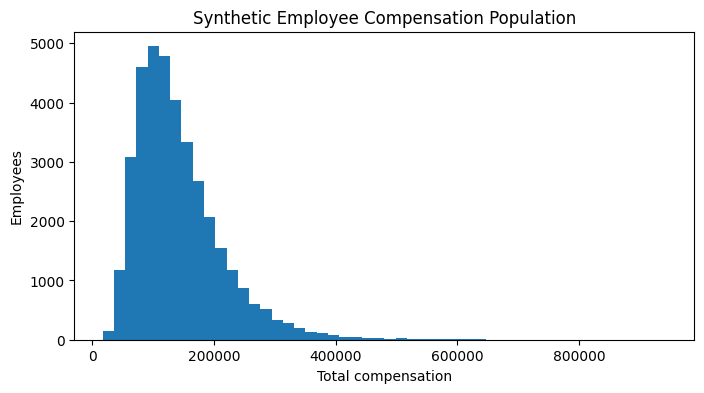

In [26]:
# Synthetic right-skewed compensation population for classroom simulation
population = np.random.lognormal(mean=11.75, sigma=0.48, size=37000)

population_median = np.median(population)
print(f"Population median (parameter): ${population_median:,.0f}")

plt.figure(figsize=(8,4))
plt.hist(population, bins=50)
plt.xlabel("Total compensation")
plt.ylabel("Employees")
plt.title("Synthetic Employee Compensation Population")
plt.show()


In [27]:
sample = np.random.choice(population, size=500, replace=False)
sample_median = np.median(sample)

print(f"Population median: ${population_median:,.0f}")
print(f"Sample median:     ${sample_median:,.0f}")
print(f"Sampling error:    ${sample_median-population_median:,.0f}")


Population median: $126,822
Sample median:     $127,852
Sampling error:    $1,030


### Discussion Q1
1. Which number is the **parameter**?
2. Which number is the **statistic**?
3. If we drew another random sample of 500 employees, would the sample median necessarily be the same?



The parameter is the population median. The statistic is the sample median. No it wouldn't be the same.

---

## Part 3 — The Bootstrap

In real applications, we normally **cannot return to the population** and repeatedly draw new samples.

The bootstrap treats the original sample as a stand-in for the population.

### Bootstrap recipe
1. Start with the original random sample of size *n*.
2. Draw *n* observations **with replacement** from that sample.
3. Calculate the statistic.
4. Repeat thousands of times.


In [28]:
# One bootstrap resample
bootstrap_sample = np.random.choice(sample, size=len(sample), replace=True)

print(f"Original sample median:  ${np.median(sample):,.0f}")
print(f"Bootstrap sample median: ${np.median(bootstrap_sample):,.0f}")
print("Unique observations in resample:", len(np.unique(bootstrap_sample)))


Original sample median:  $127,852
Bootstrap sample median: $121,270
Unique observations in resample: 304


### Discussion Q2
Why do we sample **with replacement**?



We sample with replacement so that we can find out which number has occurred twice.

### Activity 3A — Complete the bootstrap

Fill in the missing line to calculate one median for each bootstrap resample.


In [29]:
n_bootstraps = 5000
bootstrap_medians = []

for i in range(n_bootstraps):
    resample = np.random.choice(sample, size=len(sample), replace=True)


    resampled_median = np.median(resample)

    bootstrap_medians.append(resampled_median)

bootstrap_medians = np.array(bootstrap_medians)


**Hint:** use `np.median(resample)`.


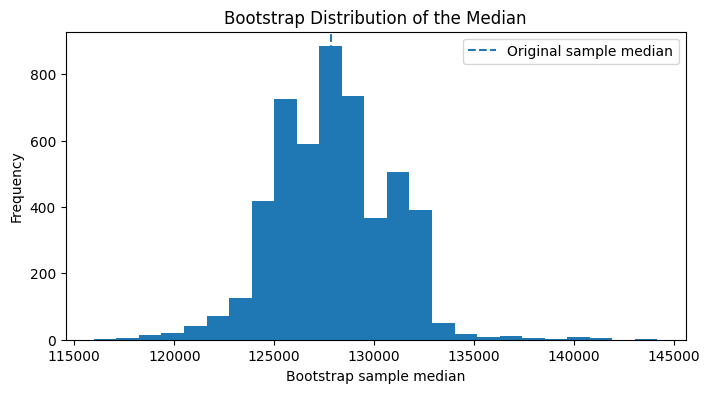

In [30]:
plt.figure(figsize=(8,4))
plt.hist(bootstrap_medians, bins=25)
plt.axvline(sample_median, linestyle='--', label='Original sample median')
plt.xlabel("Bootstrap sample median")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Median")
plt.legend()
plt.show()


---

## Part 4 — From Bootstrap Estimates to a 95% Confidence Interval

The **bootstrap percentile method** takes the middle 95% of the bootstrap estimates.

For a 95% interval:
- 2.5% lies below the lower endpoint.
- 2.5% lies above the upper endpoint.


In [31]:
ci_median_95 = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f"95% bootstrap CI: ${ci_median_95[0]:,.0f} to ${ci_median_95[1]:,.0f}")
print(f"Known population median in our simulation: ${population_median:,.0f}")
print("Does this interval capture the parameter?",
      ci_median_95[0] <= population_median <= ci_median_95[1])


95% bootstrap CI: $122,427 to $132,836
Known population median in our simulation: $126,822
Does this interval capture the parameter? True


### Confidence level
A 95% confidence level describes the **long-run performance of the procedure**.

If we repeatedly:
1. draw a new random sample,
2. bootstrap it,
3. construct a 95% interval,

then about 95% of those intervals should capture the population parameter.

It does **not** mean that 95% of individual observations lie inside the interval.


---

## Part 5 — Estimating a Population Mean

Confidence intervals are not limited to medians.

We will now use a sample of maternal ages to estimate the **population average maternal age**, paralleling the chapter's births example.


Observed sample mean age: 27.28 years


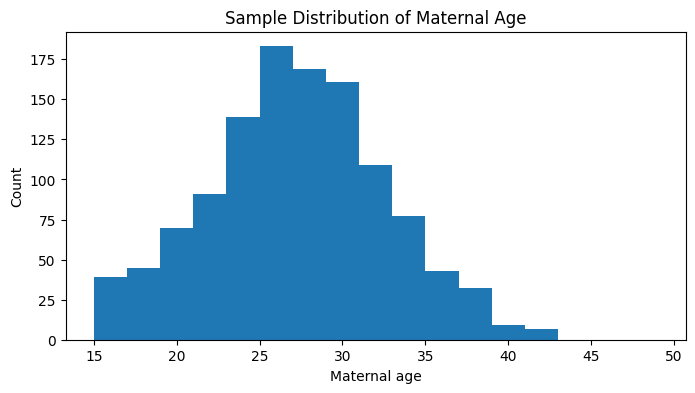

In [32]:
# Synthetic classroom sample shaped like plausible maternal ages
maternal_age = np.clip(np.random.normal(loc=27.2, scale=5.5, size=1174), 15, 48)

observed_mean = maternal_age.mean()
print(f"Observed sample mean age: {observed_mean:.2f} years")

plt.figure(figsize=(8,4))
plt.hist(maternal_age, bins=np.arange(15,50,2))
plt.xlabel("Maternal age")
plt.ylabel("Count")
plt.title("Sample Distribution of Maternal Age")
plt.show()


In [33]:
bootstrap_means = []

for i in range(5000):
    resample = np.random.choice(maternal_age, size=len(maternal_age), replace=True)
    bootstrap_means.append(np.mean(resample))

bootstrap_means = np.array(bootstrap_means)
mean_ci_95 = np.percentile(bootstrap_means, [2.5, 97.5])

print("95% CI for population average maternal age:",
      np.round(mean_ci_95, 2))


95% CI for population average maternal age: [26.98 27.59]


---

## Part 6 — When Should We Be Careful with the Bootstrap?

The bootstrap percentile method is powerful, but we need to know important limitations.

It is less reliable when:
- the original random sample is very small;
- the statistic is strongly affected by rare observations;
- we want to estimate extremes such as a population minimum or maximum;
- the bootstrap distribution of the statistic behaves poorly.



In [34]:
# Explore the problem with bootstrapping a maximum
small_sample = np.array([3, 4, 4, 5, 7, 8, 9, 12])

bootstrap_maxima = []
for i in range(5000):
    r = np.random.choice(small_sample, size=len(small_sample), replace=True)
    bootstrap_maxima.append(np.max(r))

np.unique(bootstrap_maxima, return_counts=True)


(array([ 5,  7,  8,  9, 12]), array([  21,   86,  377, 1226, 3290]))